## **Week 18 · Day 3 — Deep Q-Networks (DQN)**

### **Why this matters**

Tabular Q-learning breaks when there are too many states — imagine every pixel in a video game being a “state.”
**Deep Q-Networks (DQNs)** solve this by using a **neural network** to approximate the Q-function, enabling agents to learn directly from high-dimensional inputs.

---

### **Theory Essentials**

Neural Q-function: Qθ(s,a)≈Q∗(s,a).

Experience Replay: store and reuse past transitions to stabilize learning.

Target Network: separate copy of the Q-network for stable targets.

Loss Function:
L=[r+γmaxa′Qtarget(s′,a′)−Q(s,a)]^2

Goal: Train network weights θ to minimize temporal-difference error.

---

This is where the leap from **FrozenLake** to **CartPole** really happens 👇

---

### 🧭 1. Environment difference

You’re **no longer using a grid world (like FrozenLake)**.
Instead, `CartPole-v1` is a **continuous physics simulation** from Gymnasium.

Imagine:

* A **cart** that can move left/right.
* A **pole** attached to it, balanced upright.
* The goal: keep the pole balanced as long as possible.

So the “state” isn’t a grid coordinate anymore — it’s **4 continuous numbers** describing the system’s physics:

| Index | Meaning                    |
| :---- | :------------------------- |
| 0     | Cart position (x)          |
| 1     | Cart velocity              |
| 2     | Pole angle (θ)             |
| 3     | Pole angular velocity (θ̇) |

The **action space** is discrete though:

* `0` → push cart left
* `1` → push cart right

---

### 🪙 2. Where the rewards come from

Gym’s `CartPole-v1` defines the reward automatically:

* **Each time step the pole stays upright** → reward = **+1**
* **Episode ends** when:

  * The pole falls past 15° from vertical, or
  * The cart moves too far left/right, or
  * You reach 500 steps (max duration).

So total episode reward = **number of steps you kept the pole balanced**.
That’s why your plot’s y-axis (“Average Reward”) will increase as the agent learns to balance longer.

---

### 🧠 3. What the network learns

The DQN learns a mapping from:

> `(position, velocity, angle, angular velocity)` → how good each action is.

So instead of memorizing fixed states like a grid, it **generalizes**:

* If the pole is leaning right, pushing left likely increases reward.
* If it’s stable, small corrections keep reward flowing.

---

### 🏁 4. In short

| Concept  | FrozenLake            | CartPole                  |
| -------- | --------------------- | ------------------------- |
| State    | discrete (grid cells) | continuous (real values)  |
| Actions  | 4 directions          | 2 directions (left/right) |
| Reward   | +1 at goal only       | +1 per time step balanced |
| Learning | Q-table               | Deep Q-network            |
| Goal     | Reach goal            | Keep pole balanced        |

---


Gamma controls how much future rewards matter compared to immediate ones.

Epsilon controls how often the agent explores randomly instead of following what it already knows.

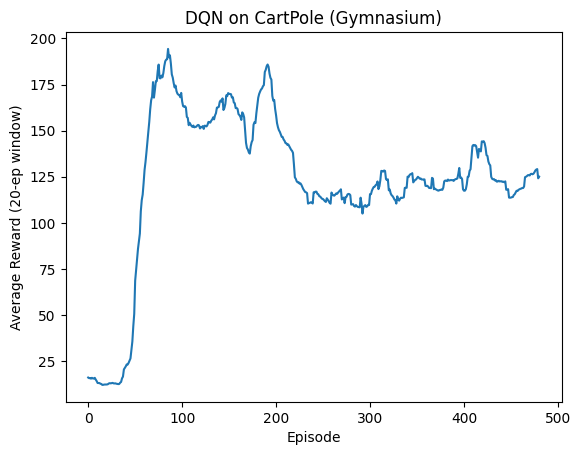

Mean reward (last 50): 121.38


In [3]:
# Setup
import numpy as np, random, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
np.random.seed(42); random.seed(42); torch.manual_seed(42)

# Environment
env = gym.make("CartPole-v1")
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n

# Q-Network
class DQN(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x): return self.net(x)

q_net = DQN()
target_net = DQN()
target_net.load_state_dict(q_net.state_dict())
optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

# Replay buffer
from collections import deque
buffer = deque(maxlen=10000)

# Hyperparams
gamma, epsilon, batch_size = 0.99, 0.1, 64
episodes, sync_freq = 500, 10

def select_action(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32)
        return int(torch.argmax(q_net(s)).item())

rewards = []
for ep in range(episodes):
    state, info = env.reset()
    total = 0.0
    terminated = truncated = False

    while not (terminated or truncated):
        action = select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        buffer.append((state, action, reward, next_state, terminated or truncated))
        state = next_state
        total += reward

        if len(buffer) >= batch_size:
            batch = random.sample(buffer, batch_size)
            s_b, a_b, r_b, s2_b, d_b = zip(*batch)

            s_b  = torch.tensor(s_b,  dtype=torch.float32)
            a_b  = torch.tensor(a_b,  dtype=torch.int64)
            r_b  = torch.tensor(r_b,  dtype=torch.float32)
            s2_b = torch.tensor(s2_b, dtype=torch.float32)
            d_b  = torch.tensor(d_b,  dtype=torch.float32)

            q_sa = q_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                max_next = target_net(s2_b).max(1)[0]
                target = r_b + gamma * max_next * (1 - d_b)
            loss = nn.functional.mse_loss(q_sa, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    if ep % sync_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    # optional epsilon decay
    #epsilon = max(0.01, epsilon * 0.995)

    rewards.append(total)

# Plot moving average
window = 20
mv = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(mv)
plt.title("DQN on CartPole (Gymnasium)")
plt.xlabel("Episode")
plt.ylabel(f"Average Reward ({window}-ep window)")
plt.show()

print("Mean reward (last 50):", np.mean(rewards[-50:]))


### 🧩 1. Environment setup

```python
env = gym.make("CartPole-v1")
n_states = env.observation_space.shape[0]   # 4 continuous inputs: position, velocity, angle, angular velocity
n_actions = env.action_space.n              # 2 discrete actions: left or right
```

So instead of a small discrete grid (like FrozenLake), we now have **continuous states** → can’t use a table.
Hence: we use a **neural network** to approximate Q(s, a).

---

### 🧠 2. Q-Network architecture

```python
class DQN(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x): return self.net(x)
```

* Input: current **state** (4 features).
* Output: **Q-values for all actions** → one number per action.
* The agent picks the action with the largest Q-value.

We create two networks:

```python
q_net = DQN()          # main network (learns every step)
target_net = DQN()     # stable copy (used to compute targets)
target_net.load_state_dict(q_net.state_dict())
```

The **target network** gives a stable reference for learning — it’s synced every few episodes (`sync_freq`).

---

### 🔁 3. Replay buffer

```python
from collections import deque
buffer = deque(maxlen=10000)
```

Stores recent experiences `(state, action, reward, next_state, done)`.
Later we sample random batches to train, breaking correlation between consecutive frames — this stabilizes learning.

---

### ⚙️ 4. Key hyperparameters

```python
gamma = 0.99       # discount factor for future rewards
epsilon = 0.1      # exploration probability (ε-greedy)
batch_size = 64
episodes = 500
sync_freq = 10     # copy q_net → target_net every 10 episodes
```

---

### 🎯 5. Action selection

```python
def select_action(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()  # explore
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32)
        return int(torch.argmax(q_net(s)).item())  # exploit
```

→ Same ε-greedy idea as tabular Q-learning.

---

### 🧠 6. Training loop

Each episode:

1. Reset environment, set total reward = 0.
2. For each step:

   * Pick action (ε-greedy).
   * Perform it → get next state, reward, done.
   * Store transition in replay buffer.
   * If enough samples in buffer, **train**:

     ```python
     batch = random.sample(buffer, batch_size)
     s_b, a_b, r_b, s2_b, d_b = zip(*batch)
     ```
   * Compute current Q-values and target Q-values:

     ```python
     q_sa = q_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)
     with torch.no_grad():
         max_next = target_net(s2_b).max(1)[0]
         target = r_b + gamma * max_next * (1 - d_b)
     loss = mse(q_sa, target)
     ```

     This is the **Bellman equation**, now learned by gradient descent.
   * Backpropagate:

     ```python
     optimizer.zero_grad()
     loss.backward()
     optimizer.step()
     ```

---

### 🧷 7. Sync networks

```python
if ep % sync_freq == 0:
    target_net.load_state_dict(q_net.state_dict())
```

→ periodically copy weights to stabilize learning.

---

### 📉 8. Epsilon decay & reward tracking

```python
epsilon = max(0.01, epsilon * 0.995)
```

→ gradually explore less and exploit more.
Then plot a moving average of rewards per episode — it should rise toward 500 (the max for CartPole).

---

### 🧩 Big picture

This code combines:

* **Neural network** = function approximator for Q(s, a)
* **Replay buffer** = uncorrelated learning samples
* **Target network** = stable reference for updates
* **Epsilon-greedy** = balance exploration/exploitation

These four are the **core ingredients of the original DeepMind DQN paper (2015)** — the foundation of modern deep reinforcement learning.

1) Core (10–15 min)

Task: Print the mean reward in the last 50 episodes — did the agent “solve” CartPole (>195)?

In [2]:
print("Mean reward (last 50 episodes):", np.mean(rewards[-50:]))


Mean reward (last 50 episodes): 268.96


2) Practice (10–15 min)

Task: Add epsilon decay to reduce exploration over time.

No decay:  Mean reward (last 50): 121.38
With decay: Mean reward (last 50): 268.96

3) Stretch (optional, 10–15 min)

Task: Track and plot the agent’s best episode trajectory (rewards per timestep).

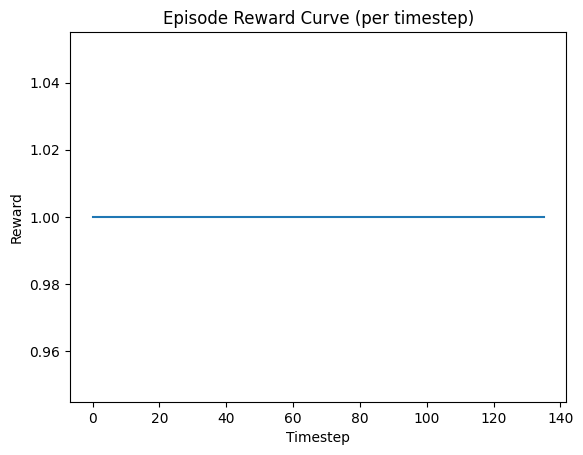

Episode length: 136 timesteps


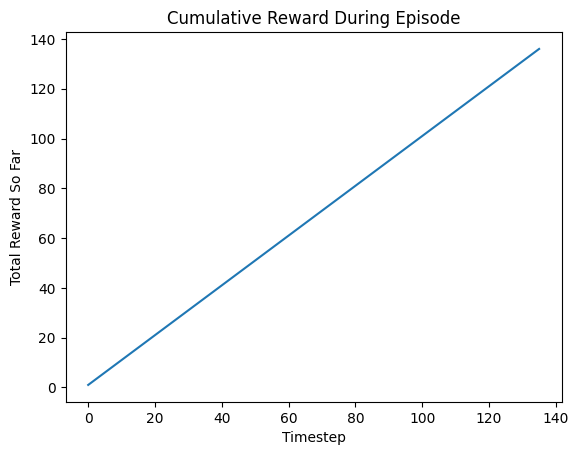

In [7]:
# Evaluate one full episode and record rewards per timestep
episode_rewards = []
state, info = env.reset()
done = False

while not done:
    # Always pick the best (greedy) action
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32)
        action = int(torch.argmax(q_net(s)).item())

    # Step in environment
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    episode_rewards.append(reward)
    state = next_state

# Plot rewards per timestep
plt.plot(episode_rewards)
plt.title("Episode Reward Curve (per timestep)")
plt.xlabel("Timestep")
plt.ylabel("Reward")
plt.show()

print(f"Episode length: {len(episode_rewards)} timesteps")

plt.plot(np.cumsum(episode_rewards))
plt.title("Cumulative Reward During Episode")
plt.xlabel("Timestep")
plt.ylabel("Total Reward So Far")
plt.show()



Mini-Challenge (≤40 min) — “CartPole Solver”

Goal: Tune hyperparameters (lr, γ, hidden size) to consistently reach ≥195 average reward.

Acceptance Criteria:

Runs successfully to solve environment (≥195 mean).

Uses replay buffer + target network.

Plots reward curve over episodes.

Reports best hyperparameter combination.

Hint: Start with:

lr = 1e-3, gamma = 0.99, hidden = [128, 128]

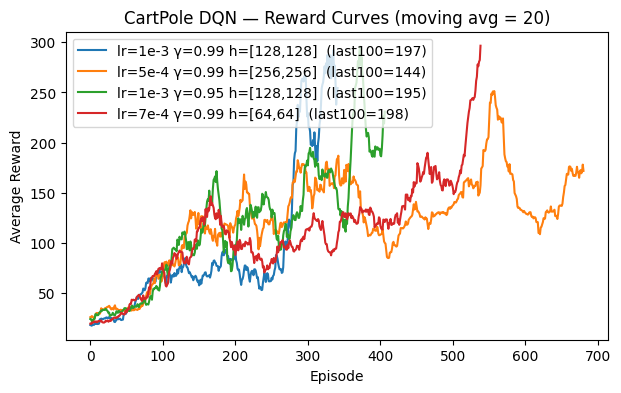

Best config: {'lr': 0.0007, 'gamma': 0.99, 'hidden': (64, 64), 'label': 'lr=7e-4 γ=0.99 h=[64,64]'} 
Last-100 mean reward: 198.14 
Solved? YES


In [8]:
import numpy as np, random, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
from collections import deque

# Repro
np.random.seed(42); random.seed(42); torch.manual_seed(42)

env = gym.make("CartPole-v1")
n_states = env.observation_space.shape[0]
n_actions = env.action_space.n
device = torch.device("cpu")

# ----- DQN model factory -----
class DQN(nn.Module):
    def __init__(self, hidden_sizes=(128,128)):
        super().__init__()
        layers = []
        in_dim = n_states
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers += [nn.Linear(in_dim, n_actions)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        if x.ndim == 1: x = x.unsqueeze(0)
        return self.net(x)

# ----- train one config -----
def train_dqn(lr=1e-3, gamma=0.99, hidden=(128,128),
              episodes=500, batch_size=64, buffer_size=20000,
              eps_start=1.0, eps_end=0.01, eps_decay=0.995,
              sync_freq=10, max_steps=500):
    q_net = DQN(hidden).to(device)
    target_net = DQN(hidden).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    buffer = deque(maxlen=buffer_size)
    rewards = []
    epsilon = eps_start

    for ep in range(episodes):
        s, info = env.reset()
        terminated = truncated = False
        total = 0.0

        for t in range(max_steps):
            # ε-greedy
            if np.random.rand() < epsilon:
                a = env.action_space.sample()
            else:
                with torch.no_grad():
                    a = int(torch.argmax(q_net(torch.tensor(s, dtype=torch.float32, device=device))).item())

            s2, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            buffer.append((s, a, r, s2, done))
            s = s2
            total += r

            # update
            if len(buffer) >= batch_size:
                batch = random.sample(buffer, batch_size)
                sb, ab, rb, s2b, db = zip(*batch)
                sb  = torch.tensor(sb,  dtype=torch.float32, device=device)
                ab  = torch.tensor(ab,  dtype=torch.int64,   device=device)
                rb  = torch.tensor(rb,  dtype=torch.float32, device=device)
                s2b = torch.tensor(s2b, dtype=torch.float32, device=device)
                db  = torch.tensor(db,  dtype=torch.float32, device=device)

                q_sa = q_net(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    max_next = target_net(s2b).max(1)[0]
                    target = rb + gamma * max_next * (1 - db)

                loss = nn.functional.mse_loss(q_sa, target)
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            if done: break

        rewards.append(total)

        # target sync + epsilon decay
        if ep % sync_freq == 0:
            target_net.load_state_dict(q_net.state_dict())
        epsilon = max(eps_end, epsilon * eps_decay)

        # optional early stop when solved
        if len(rewards) >= 100 and np.mean(rewards[-100:]) >= 195:
            break

    return rewards, q_net

# ----- sweep configs -----
configs = [
    {"lr":1e-3,  "gamma":0.99, "hidden":(128,128), "label":"lr=1e-3 γ=0.99 h=[128,128]"},
    {"lr":5e-4,  "gamma":0.99, "hidden":(256,256), "label":"lr=5e-4 γ=0.99 h=[256,256]"},
    {"lr":1e-3,  "gamma":0.95, "hidden":(128,128), "label":"lr=1e-3 γ=0.95 h=[128,128]"},
    {"lr":7e-4,  "gamma":0.99, "hidden":(64,64),   "label":"lr=7e-4 γ=0.99 h=[64,64]"},
]

results = []
plt.figure(figsize=(7,4))
for cfg in configs:
    rewards, _ = train_dqn(lr=cfg["lr"], gamma=cfg["gamma"], hidden=cfg["hidden"], episodes=700)
    mv = np.convolve(rewards, np.ones(20)/20, mode="valid")
    results.append((np.mean(rewards[-100:]) if len(rewards)>=100 else np.mean(rewards),
                    cfg, rewards))
    plt.plot(mv, label=f'{cfg["label"]}  (last100={np.mean(rewards[-100:]):.0f})')

plt.title("CartPole DQN — Reward Curves (moving avg = 20)")
plt.xlabel("Episode"); plt.ylabel("Average Reward"); plt.legend(); plt.show()

# ----- report best -----
best_mean, best_cfg, best_rewards = max(results, key=lambda x: x[0])
print("Best config:", best_cfg, f"\nLast-100 mean reward: {best_mean:.2f}",
      f"\nSolved? {'YES' if best_mean >= 195 else 'NO'}")


Notes / Key Takeaways

DQN combines deep learning + reinforcement learning.

Replay buffer avoids correlation between samples.

Target network stabilizes learning by keeping older parameters fixed.

The agent learns from its own experience, not direct supervision.

Solving CartPole = sustained balance (average reward ≥195 for 100 episodes).

Reflection

Why do we need both a replay buffer and a target network?

How does a DQN differ fundamentally from tabular Q-learning?

1. Why do we need both a replay buffer and a target network?

The replay buffer stores past experiences and lets the agent learn from random batches instead of consecutive frames.
→ This breaks correlation between similar steps, making learning more stable and data-efficient.

The target network provides a fixed reference for the Q-value targets for several updates.
→ Without it, both sides of the Bellman equation would change every step, causing instability and oscillation.

Together, they make training deep Q-networks much more stable and prevent “chasing a moving target.”

2. How does a DQN differ fundamentally from tabular Q-learning?

Representation: Tabular Q-learning stores one Q-value per (state, action) pair → only works for small, discrete spaces.
DQN uses a neural network to approximate Q(s, a) for continuous or large state spaces.

Learning process: DQN learns from batches of replayed experience with gradient descent; tabular Q-learning updates one sample at a time with direct arithmetic.

Generalization: DQN can generalize to unseen states; tabular cannot—it memorizes exact states.